## project: LIC Insurance Data Analysis using Python
## Tools: Python, Pandas,NumPy,Matplotilib,Seaborn,Jupyter Notebook

# 1. Import Libraries

In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2.Load dataset

In [6]:
df = pd.read_csv(
    "C:/Users/DELL/Downloads/LIC_Python_Project_Dataset_5000.csv",
    parse_dates=["Policy_Start_Date"]
)

df.head()

,Policy_ID,Customer_Age,Gender,City,State,Policy_Type,Premium_Amount,Sum_Assured,Policy_Term_Years,Payment_Mode,Policy_Status,Claim_Status,Claim_Amount,Agent_ID,Policy_Start_Date,Age_Group,Year,Month
0,LIC100000,32,Male,Hyderabad,Telangana,Whole Life,39100,373000,15,Monthly,Active,Not Claimed,0,AG1275,2021-12-26,26-35,2021,2021-12
1,LIC100001,41,Female,Varanasi,Uttar Pradesh,Money Back,33500,761000,25,Half-Yearly,Active,Not Claimed,0,AG1257,2025-07-11,36-45,2025,2025-07
2,LIC100002,33,Female,Surat,Gujarat,Endowment,39800,967000,15,Half-Yearly,Matured,Claimed,708000,AG1088,2023-10-02,26-35,2023,2023-10
3,LIC100003,31,Female,Patna,Bihar,Endowment,26200,422000,12,Monthly,Active,Not Claimed,0,AG1216,2024-04-07,26-35,2024,2024-04
4,LIC100004,32,Female,Ahmedabad,Gujarat,ULIP,36700,432000,15,Quarterly,Active,Not Claimed,0,AG1284,2026-01-31,26-35,2026,2026-01


# 3.Dataset Information

In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 5000
Columns: 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Policy_ID          5000 non-null   object        
 1   Customer_Age       5000 non-null   int64         
 2   Gender             5000 non-null   object        
 3   City               4990 non-null   object        
 4   State              5000 non-null   object        
 5   Policy_Type        5000 non-null   object        
 6   Premium_Amount     5000 non-null   int64         
 7   Sum_Assured        5000 non-null   int64         
 8   Policy_Term_Years  5000 non-null   int64         
 9   Payment_Mode       4990 non-null   object        
 10  Policy_Status      5000 non-null   object        
 11  Claim_Status       5000 non-null   object        
 12  Claim_Amount       5000 non-null   int64         
 13  Agent_ID           4990 non-null   objec

# 4.Basic Statistical Analysis

In [8]:
df.describe()

,Customer_Age,Premium_Amount,Sum_Assured,Policy_Term_Years,Claim_Amount,Year
count,5000.00000,5000.000000,5.000000e+03,5000.000000,5.000000e+03,5000.000000
mean,39.00980,39164.640000,6.459200e+05,16.641200,2.816160e+04,2021.810000
std,10.67193,18835.836573,3.768296e+05,6.253854,1.299844e+05,2.505345
min,18.00000,3700.000000,1.000000e+05,5.000000,0.000000e+00,2018.000000
25%,31.00000,25200.000000,3.600000e+05,12.000000,0.000000e+00,2020.000000
50%,39.00000,38000.000000,5.710000e+05,15.000000,0.000000e+00,2022.000000
75%,46.00000,50500.000000,8.620000e+05,20.000000,0.000000e+00,2024.000000
max,75.00000,159600.000000,3.229000e+06,30.000000,1.891000e+06,2026.000000


# 5.Check Missing values

In [9]:
df.isnull().sum()

Policy_ID             0
Customer_Age          0
Gender                0
City                 10
State                 0
Policy_Type           0
Premium_Amount        0
Sum_Assured           0
Policy_Term_Years     0
Payment_Mode         10
Policy_Status         0
Claim_Status          0
Claim_Amount          0
Agent_ID             10
Policy_Start_Date     0
Age_Group             0
Year                  0
Month                 0
dtype: int64

# 6.Remove Duplicate Records

In [10]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


# 7.Convert Data Column

In [11]:
df["Policy_Start_Date"] = pd.to_datetime(
    df["Policy_Start_Date"],
    errors="coerce"
)

df["Year"] = df["Policy_Start_Date"].dt.year
df["Month"] = df["Policy_Start_Date"].dt.month
df["Month_Name"] = df["Policy_Start_Date"].dt.strftime("%b")
print(df.head())
print(df.shape)

   Policy_ID  Customer_Age  Gender       City          State Policy_Type  \
0  LIC100000            32    Male  Hyderabad      Telangana  Whole Life   
1  LIC100001            41  Female   Varanasi  Uttar Pradesh  Money Back   
2  LIC100002            33  Female      Surat        Gujarat   Endowment   
3  LIC100003            31  Female      Patna          Bihar   Endowment   
4  LIC100004            32  Female  Ahmedabad        Gujarat        ULIP   

   Premium_Amount  Sum_Assured  Policy_Term_Years Payment_Mode Policy_Status  \
0           39100       373000                 15      Monthly        Active   
1           33500       761000                 25  Half-Yearly        Active   
2           39800       967000                 15  Half-Yearly       Matured   
3           26200       422000                 12      Monthly        Active   
4           36700       432000                 15    Quarterly        Active   

  Claim_Status  Claim_Amount Agent_ID Policy_Start_Date Age_Gr

# 8.KPI Analysis

In [12]:
total_policies = df["Policy_ID"].nunique()

total_premium = df["Premium_Amount"].sum()

average_premium = df["Premium_Amount"].mean()

total_sum_assured = df["Sum_Assured"].sum()

total_claim_amount = df["Claim_Amount"].sum()

claimed_policies = (df["Claim_Status"] == "Claimed").sum()

claim_rate = claimed_policies / total_policies * 100

print("Total Policies:", total_policies)
print("Total Premium:", round(total_premium, 2))
print("Average Premium:", round(average_premium, 2))
print("Total Sum Assured:", round(total_sum_assured, 2))
print("Total Claim Amount:", round(total_claim_amount, 2))
print("Claimed Policies:", claimed_policies)
print("Claim Rate:", round(claim_rate, 2), "%")

Total Policies: 5000
Total Premium: 195823200
Average Premium: 39164.64
Total Sum Assured: 3229600000
Total Claim Amount: 140808000
Claimed Policies: 345
Claim Rate: 6.9 %


# .CHARTS

# 9.Policy Count by Policy Type

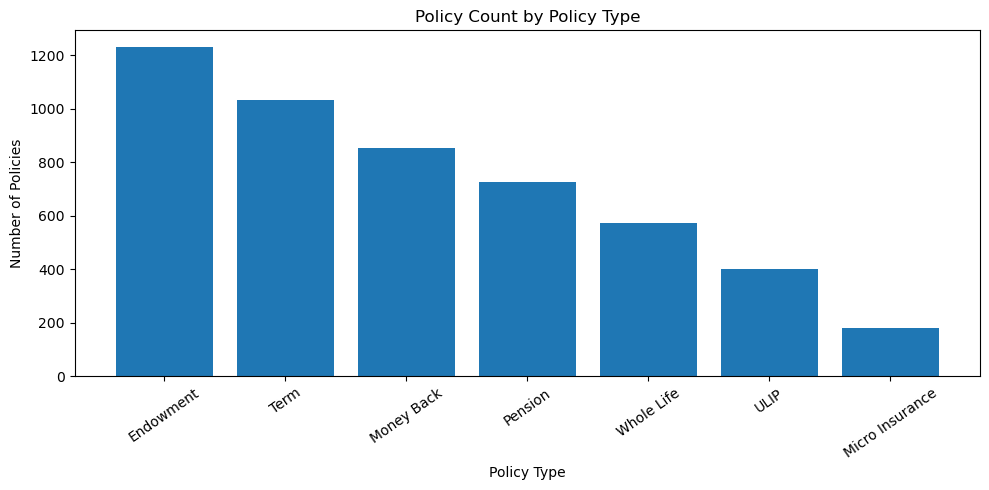

In [13]:
policy_count = df["Policy_Type"].value_counts()

plt.figure(figsize=(10,5))

plt.bar(
    policy_count.index,
    policy_count.values
)

plt.title("Policy Count by Policy Type")
plt.xlabel("Policy Type")
plt.ylabel("Number of Policies")
plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

# 10.Total Premium by Policy Type

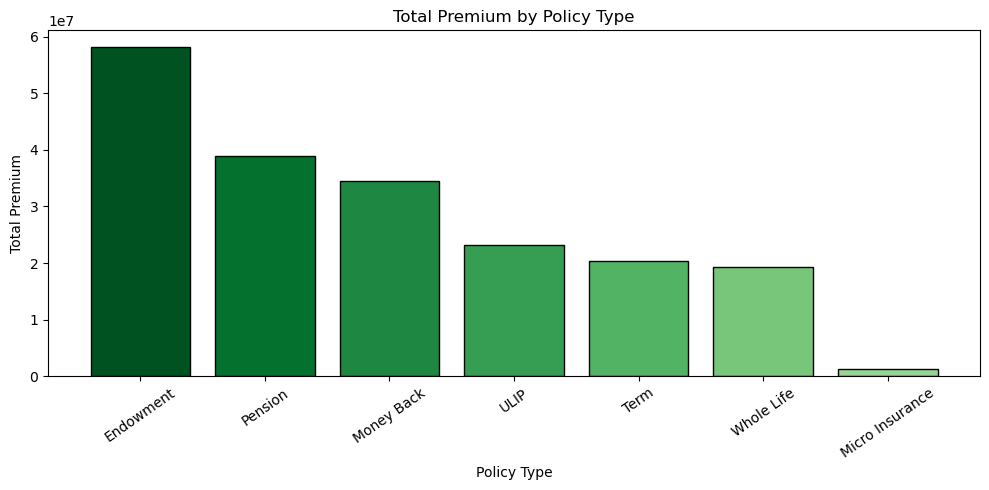

In [60]:
import matplotlib.pyplot as plt
import numpy as np

premium_by_type = (
    df.groupby("Policy_Type")["Premium_Amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

colors = plt.cm.Greens(np.linspace(0.95, 0.4, len(premium_by_type)))

plt.bar(
    premium_by_type.index,
    premium_by_type.values,
    color=colors,
    edgecolor='black'
)

plt.title("Total Premium by Policy Type")
plt.xlabel("Policy Type")
plt.ylabel("Total Premium")
plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

# Average Premimum by Policy Type

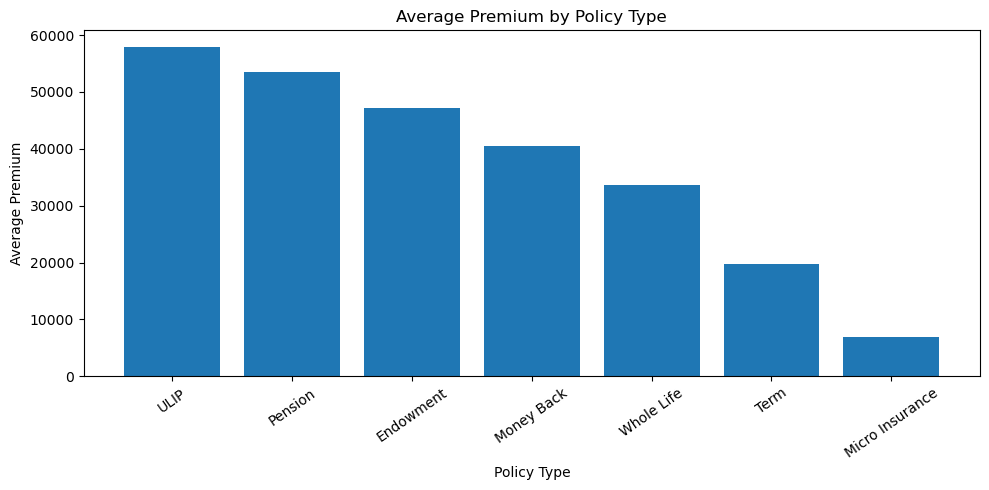

In [15]:
avg_premium_type = (
    df.groupby("Policy_Type")["Premium_Amount"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

plt.bar(
    avg_premium_type.index,
    avg_premium_type.values
)

plt.title("Average Premium by Policy Type")
plt.xlabel("Policy Type")
plt.ylabel("Average Premium")
plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

# Top 10 Cities by Number of Policies

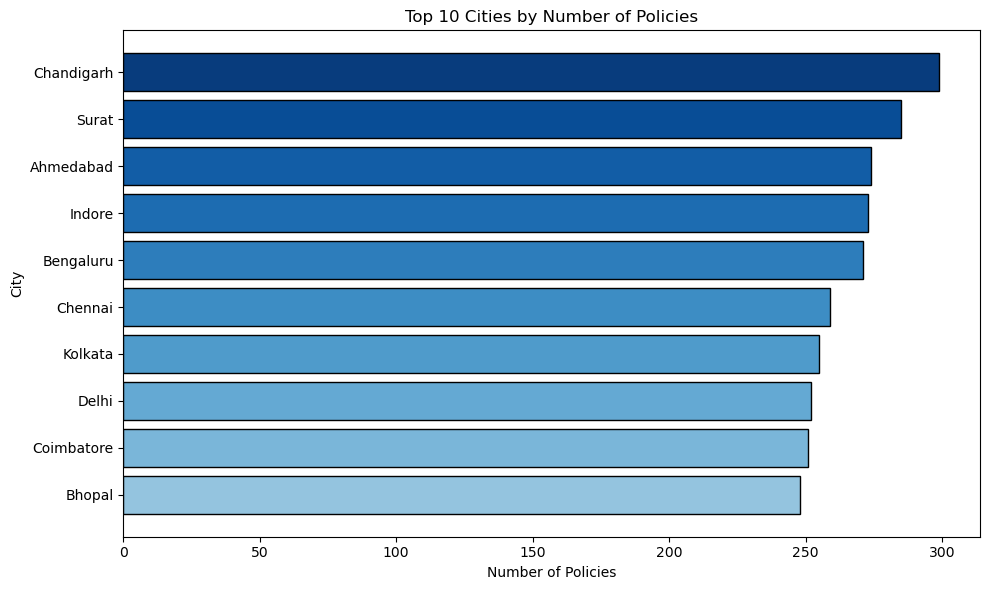

In [59]:
import matplotlib.pyplot as plt
import numpy as np

city_policy_count = (
    df["City"]
    .value_counts()
    .nlargest(10)
    .sort_values()
)

plt.figure(figsize=(10,6))

colors = plt.cm.Blues(np.linspace(0.4, 0.95, len(city_policy_count)))

plt.barh(
    city_policy_count.index,
    city_policy_count.values,
    color=colors,
    edgecolor='black'
)

plt.title("Top 10 Cities by Number of Policies")
plt.xlabel("Number of Policies")
plt.ylabel("City")

plt.tight_layout()
plt.show()

# 13.Top 10 Cities by Total premimum

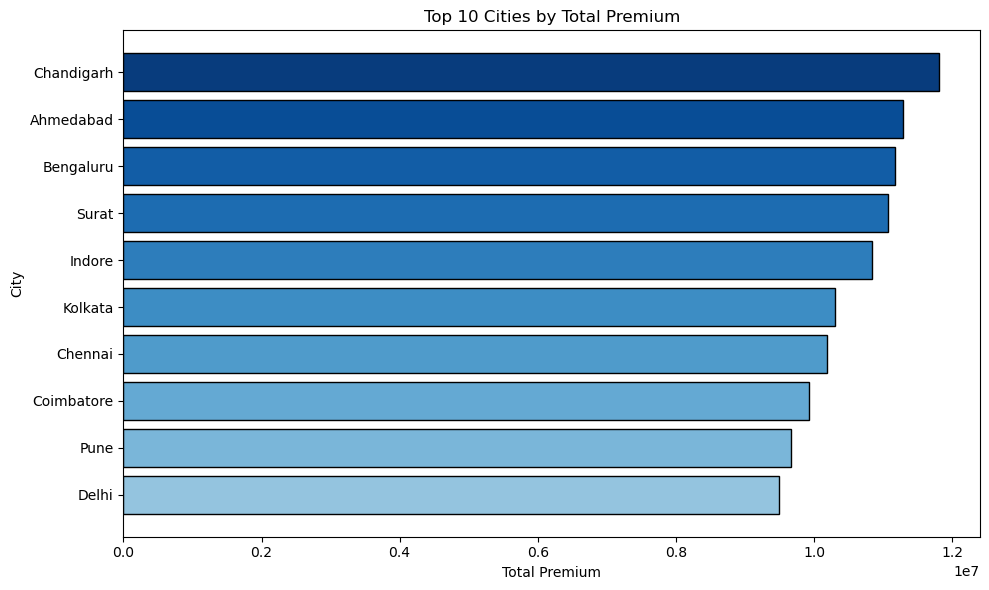

In [58]:
import matplotlib.pyplot as plt
import numpy as np

city_premium = (
    df.groupby("City")["Premium_Amount"]
    .sum()
    .nlargest(10)
    .sort_values()
)

plt.figure(figsize=(10,6))

# Upper dark, niche light - Gradient
colors = plt.cm.Blues(np.linspace(0.4, 0.95, len(city_premium)))

plt.barh(
    city_premium.index,
    city_premium.values,
    color=colors,
    edgecolor='black'
)

plt.title("Top 10 Cities by Total Premium")
plt.xlabel("Total Premium")
plt.ylabel("City")

plt.tight_layout()
plt.show()

# 14.Gender Distributition

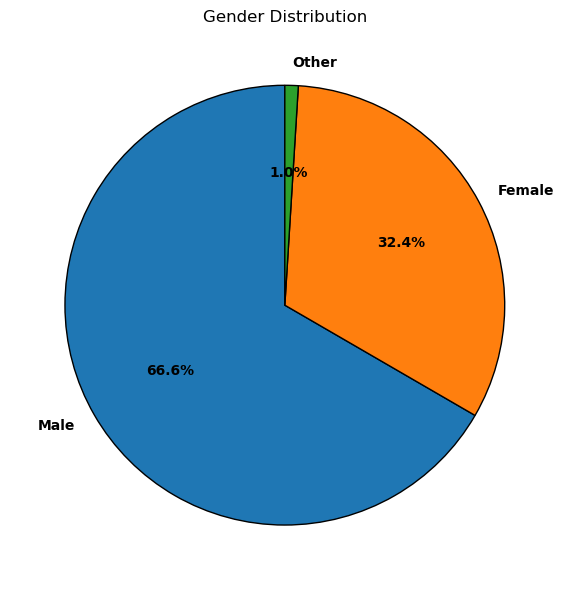

In [57]:
import matplotlib.pyplot as plt

gender_count = df["Gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_count.values,
    labels=gender_count.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black'},
    textprops={'fontweight': 'bold'}
)

plt.title("Gender Distribution")
plt.tight_layout()
plt.show()

# 15.Age group Distribution

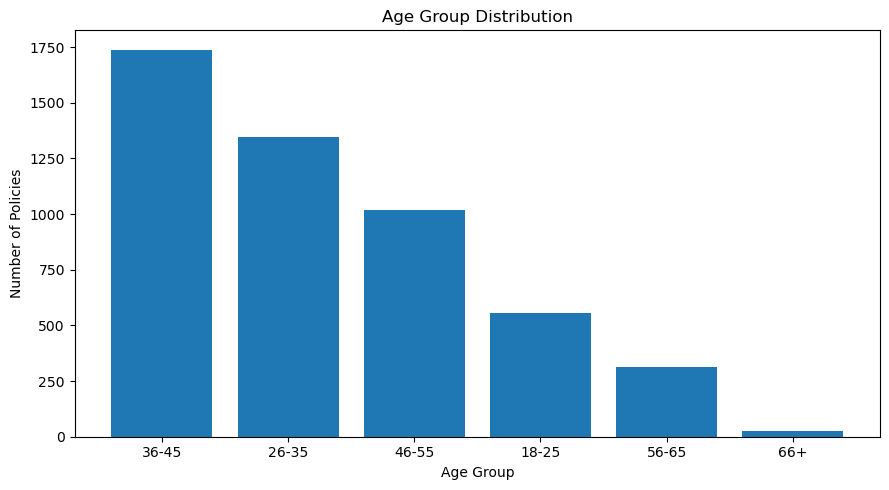

In [19]:
age_count = df["Age_Group"].value_counts()

plt.figure(figsize=(9,5))

plt.bar(
    age_count.index,
    age_count.values
)

plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Policies")

plt.tight_layout()
plt.show()

# 16.Payment Mode Distribution

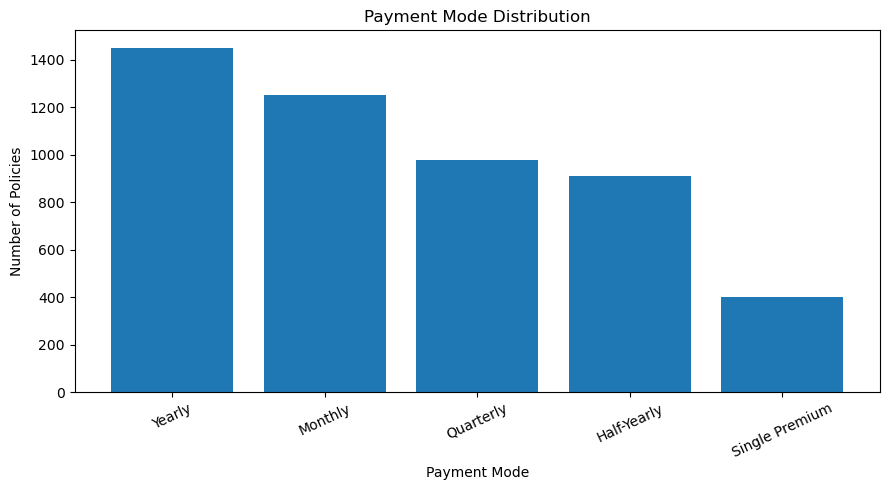

In [20]:
payment_count = df["Payment_Mode"].value_counts()

plt.figure(figsize=(9,5))

plt.bar(
    payment_count.index,
    payment_count.values
)

plt.title("Payment Mode Distribution")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Policies")
plt.xticks(rotation=25)

plt.tight_layout()
plt.show()

# 17.Policy status Distribution

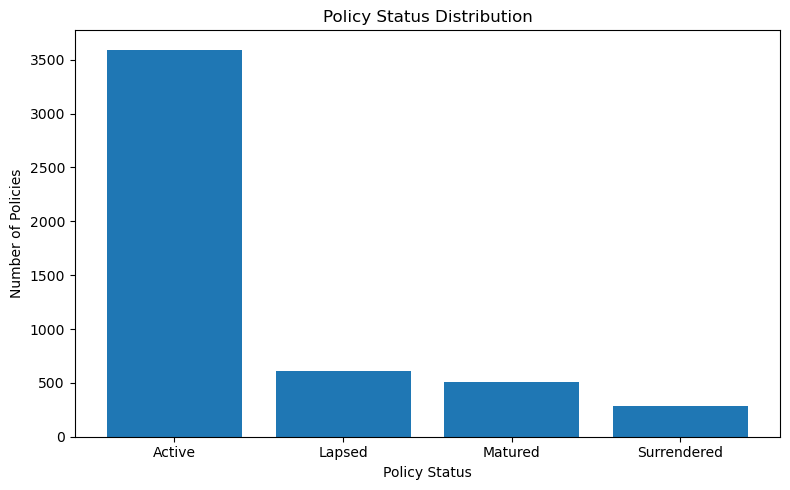

In [21]:
status_count = df["Policy_Status"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    status_count.index,
    status_count.values
)

plt.title("Policy Status Distribution")
plt.xlabel("Policy Status")
plt.ylabel("Number of Policies")

plt.tight_layout()
plt.show()

# 18. Claim Status Distribution

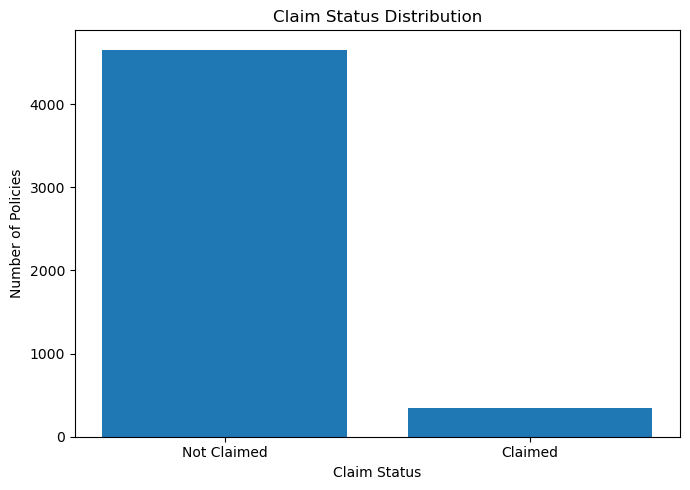

In [22]:
claim_count = df["Claim_Status"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(
    claim_count.index,
    claim_count.values
)

plt.title("Claim Status Distribution")
plt.xlabel("Claim Status")
plt.ylabel("Number of Policies")

plt.tight_layout()
plt.show()

# 19.Claim Rate by Policy Type

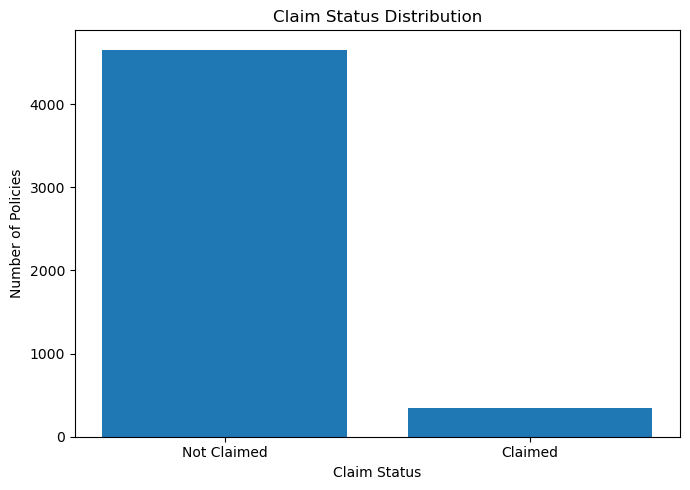

In [23]:
claim_count = df["Claim_Status"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(
    claim_count.index,
    claim_count.values
)

plt.title("Claim Status Distribution")
plt.xlabel("Claim Status")
plt.ylabel("Number of Policies")

plt.tight_layout()
plt.show()

# 20.Yearly Policy Acquisition Trend

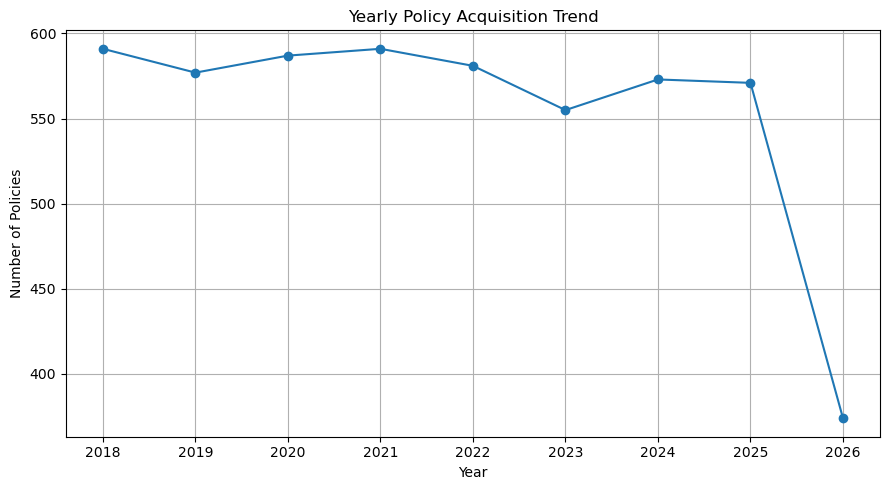

In [24]:
yearly_policy = (
    df.groupby("Year")["Policy_ID"]
    .count()
)

plt.figure(figsize=(9,5))

plt.plot(
    yearly_policy.index,
    yearly_policy.values,
    marker="o"
)

plt.title("Yearly Policy Acquisition Trend")
plt.xlabel("Year")
plt.ylabel("Number of Policies")

plt.grid()
plt.tight_layout()
plt.show()

# 21.yearly Premimum Treand

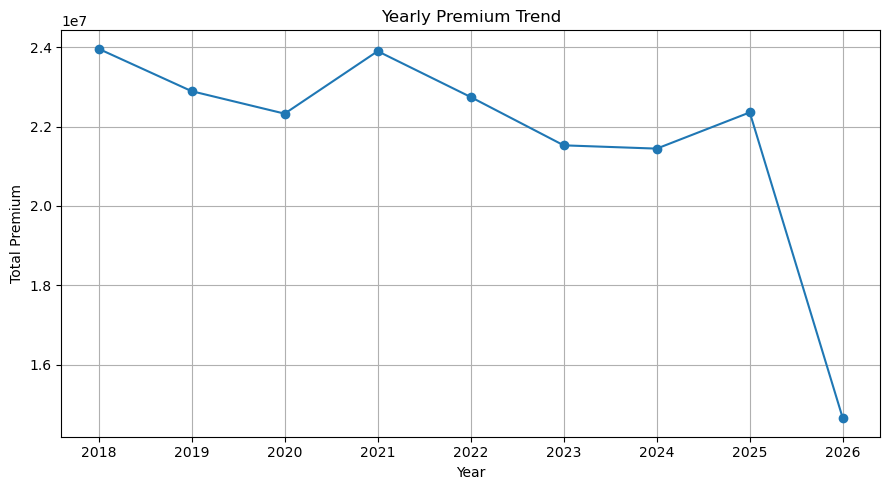

In [25]:
yearly_premium = (
    df.groupby("Year")["Premium_Amount"]
    .sum()
)

plt.figure(figsize=(9,5))

plt.plot(
    yearly_premium.index,
    yearly_premium.values,
    marker="o"
)

plt.title("Yearly Premium Trend")
plt.xlabel("Year")
plt.ylabel("Total Premium")

plt.grid()
plt.tight_layout()
plt.show()

# 22.Monthly Premium Trend

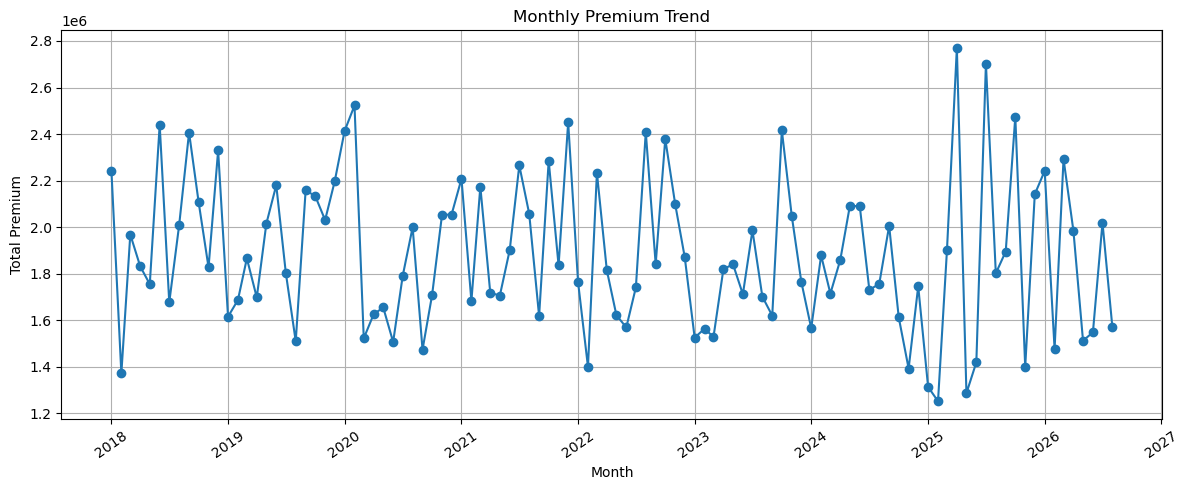

In [26]:
monthly_premium = (
    df.groupby(["Year", "Month"])["Premium_Amount"]
    .sum()
    .reset_index()
)

monthly_premium["Period"] = pd.to_datetime(
    monthly_premium["Year"].astype(str)
    + "-"
    + monthly_premium["Month"].astype(str)
    + "-01"
)

monthly_premium = monthly_premium.sort_values("Period")

plt.figure(figsize=(12,5))

plt.plot(
    monthly_premium["Period"],
    monthly_premium["Premium_Amount"],
    marker="o"
)

plt.title("Monthly Premium Trend")
plt.xlabel("Month")
plt.ylabel("Total Premium")

plt.xticks(rotation=35)
plt.grid()

plt.tight_layout()
plt.show()

# 23. Top 10Agents by Total Premium

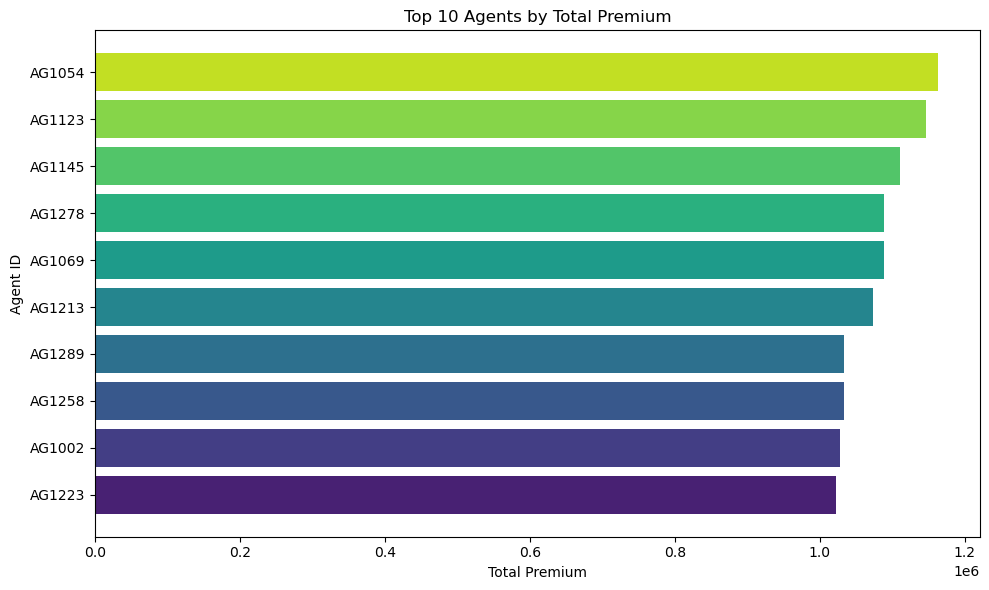

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

agent_premium = (
    df.groupby("Agent_ID")["Premium_Amount"]
    .sum()
    .nlargest(10)
    .sort_values()
)

plt.figure(figsize=(10,6))
plt.barh(agent_premium.index.astype(str), agent_premium.values, color=sns.color_palette("viridis", 10))
plt.title("Top 10 Agents by Total Premium")
plt.xlabel("Total Premium")
plt.ylabel("Agent ID")
plt.tight_layout()
plt.show()

# 24. Premium vs Sum Assured

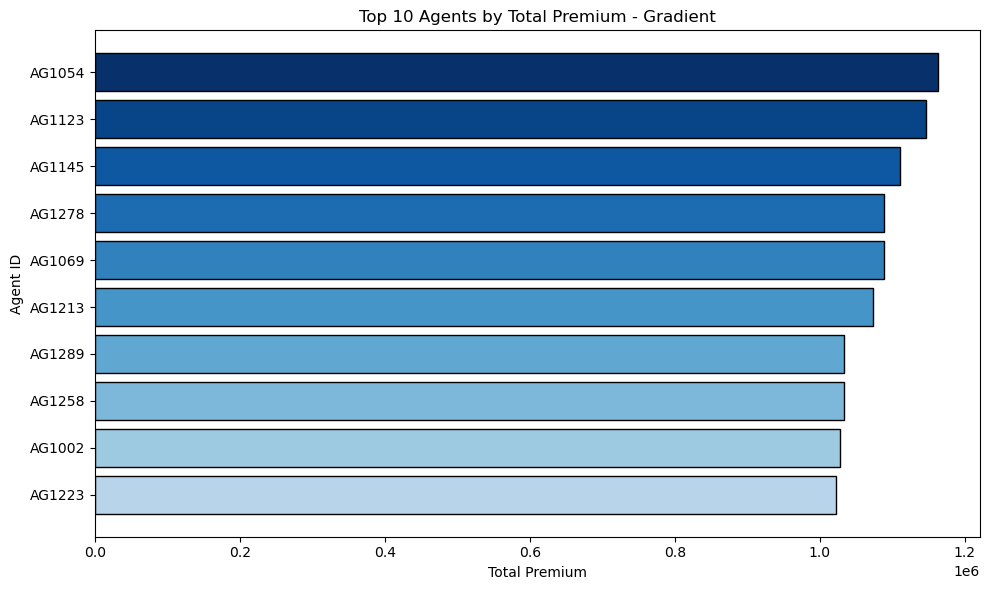

In [55]:
import matplotlib.pyplot as plt
import numpy as np

top10 = df.groupby("Agent_ID")["Premium_Amount"].sum().nlargest(10).sort_values()

plt.figure(figsize=(10,6))
plt.barh(top10.index.astype(str), top10.values, color=plt.cm.Blues(np.linspace(0.3, 1, 10)), edgecolor='black')
plt.title("Top 10 Agents by Total Premium - Gradient")
plt.xlabel("Total Premium")
plt.ylabel("Agent ID")
plt.tight_layout()
plt.show()

# 25.Customer Age vs Premium

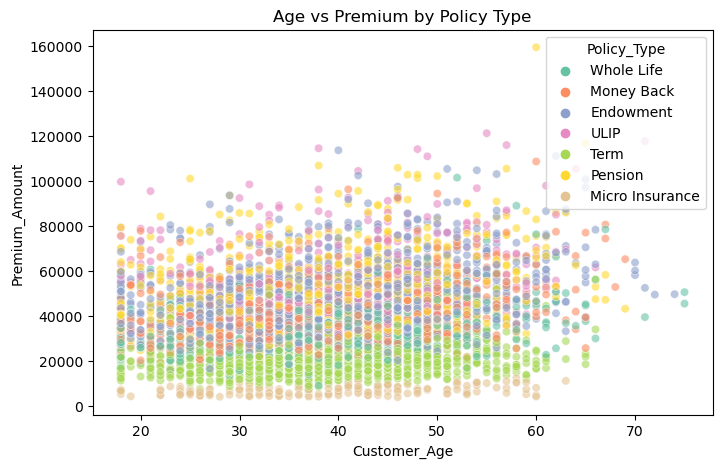

In [54]:
import seaborn as sns
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Customer_Age", y="Premium_Amount", hue="Policy_Type", palette="Set2", alpha=0.6)
plt.title("Age vs Premium by Policy Type")
plt.show()

# 26. Premium Distribution

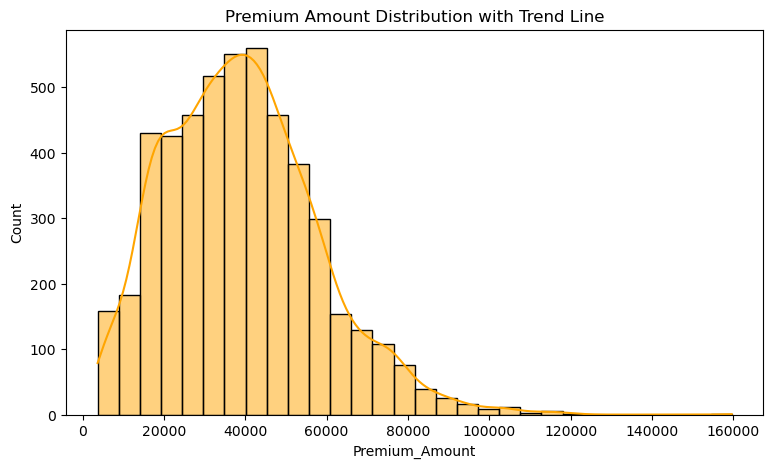

In [51]:
import seaborn as sns
plt.figure(figsize=(9,5))
sns.histplot(df["Premium_Amount"], bins=30, kde=True, color='orange')
plt.title("Premium Amount Distribution with Trend Line")
plt.show()

# 27.Premium Distribution by Policy Type Boxplot

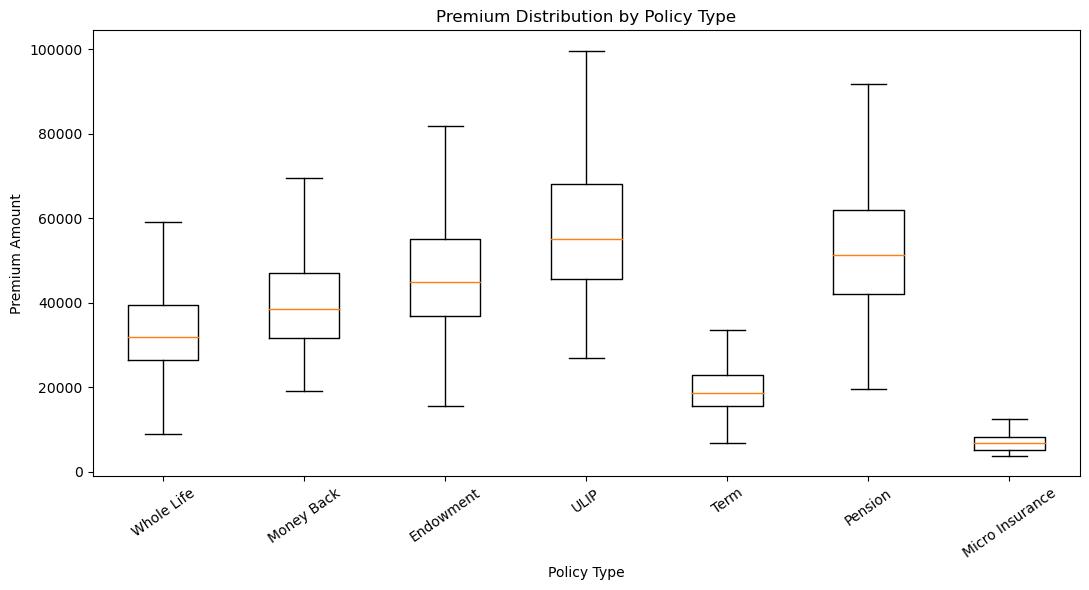

In [33]:
policy_types = df["Policy_Type"].unique()

box_data = [
    df.loc[
        df["Policy_Type"] == policy,
        "Premium_Amount"
    ]
    for policy in policy_types
]

plt.figure(figsize=(11,6))

plt.boxplot(
    box_data,
    labels=policy_types,
    showfliers=False
)

plt.title("Premium Distribution by Policy Type")
plt.xlabel("Policy Type")
plt.ylabel("Premium Amount")

plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

# 28.Correlation Heatmap

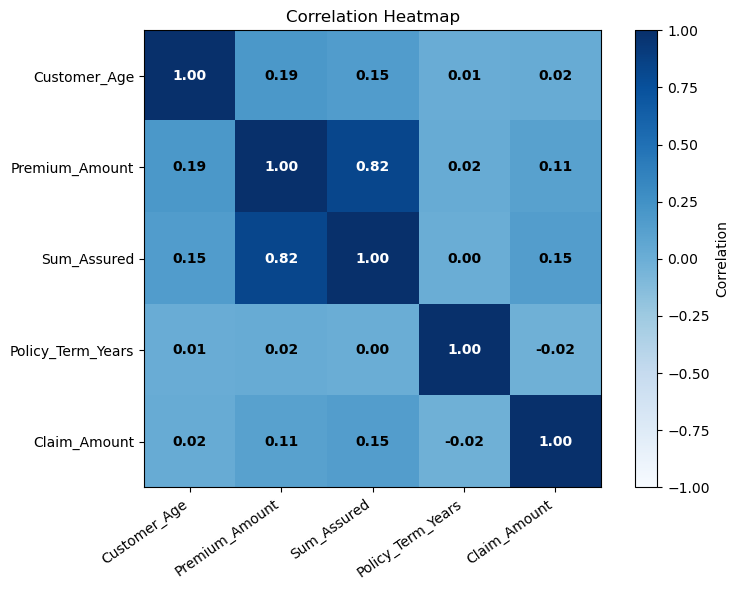

In [61]:
import matplotlib.pyplot as plt
import numpy as np

numeric_columns = [
    "Customer_Age",
    "Premium_Amount",
    "Sum_Assured",
    "Policy_Term_Years",
    "Claim_Amount"
]

corr = df[numeric_columns].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='Blues', vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(numeric_columns)), numeric_columns, rotation=35, ha="right")
plt.yticks(range(len(numeric_columns)), numeric_columns)

# text color fix
for i in range(len(numeric_columns)):
    for j in range(len(numeric_columns)):
        value = corr.iloc[i, j]
        color = "white" if abs(value) > 0.5 else "black"
        plt.text(j, i, f"{value:.2f}", ha="center", va="center", color=color, fontweight="bold")

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# ANALYSIS & INSIGHTS

# 29.Most Popular Policy

In [36]:
most_popular_policy = df["Policy_Type"].value_counts().idxmax()

print(
    "Most Popular Policy Type:",
    most_popular_policy
)

Most Popular Policy Type: Endowment


# 30. Highest Premium Policy

In [37]:
highest_premium_policy = (
    df.groupby("Policy_Type")["Premium_Amount"]
    .sum()
    .idxmax()
)

print(
    "Policy Type with Highest Total Premium:",
    highest_premium_policy
)

Policy Type with Highest Total Premium: Endowment


# 30. Highest Average Premium

In [38]:
highest_avg_premium = (
    df.groupby("Policy_Type")["Premium_Amount"]
    .mean()
    .idxmax()
)

print(
    "Highest Average Premium Policy:",
    highest_avg_premium
)

Highest Average Premium Policy: ULIP


# 32.Top City 

In [39]:
top_city = (
    df.groupby("City")["Premium_Amount"]
    .sum()
    .idxmax()
)

print("Top City by Premium:", top_city)

Top City by Premium: Chandigarh


# 33.Top Agent

In [40]:
top_agent = (
    df.groupby("Agent_ID")["Premium_Amount"]
    .sum()
    .idxmax()
)

print("Top Agent:", top_agent)

Top Agent: AG1054


# 34.Most common Payment mode

In [41]:
most_common_payment = (
    df["Payment_Mode"]
    .value_counts()
    .idxmax()
)

print(
    "Most Common Payment Mode:",
    most_common_payment
)

Most Common Payment Mode: Yearly


# 35.Most Common Policy Status

In [42]:
most_common_status = (
    df["Policy_Status"]
    .value_counts()
    .idxmax()
)

print(
    "Most Common Policy Status:",
    most_common_status
)

Most Common Policy Status: Active


# 36.Highest claim Rate Policy

In [43]:
claim_rate = (
    df.assign(
        Claimed=df["Claim_Status"] == "Claimed"
    )
    .groupby("Policy_Type")["Claimed"]
    .mean()
    .mul(100)
)

highest_claim_policy = claim_rate.idxmax()

print(
    "Highest Claim Rate Policy:",
    highest_claim_policy
)

print(
    "Claim Rate:",
    round(claim_rate.max(), 2),
    "%"
)

Highest Claim Rate Policy: ULIP
Claim Rate: 7.73 %


# 37.Gender With Highest Policy Count

In [44]:
top_gender = df["Gender"].value_counts().idxmax()

print(
    "Gender with Highest Policy Count:",
    top_gender
)

Gender with Highest Policy Count: Male


# 38.Hisghest Premium Year

In [45]:
highest_premium_year = (
    df.groupby("Year")["Premium_Amount"]
    .sum()
    .idxmax()
)

print(
    "Highest Premium Year:",
    highest_premium_year
)

Highest Premium Year: 2018


# 39.Highest Policy Acquisition Year

In [46]:
highest_policy_year = (
    df.groupby("Year")["Policy_ID"]
    .count()
    .idxmax()
)

print(
    "Highest Policy Acquisition Year:",
    highest_policy_year
)

Highest Policy Acquisition Year: 2018


# FINAL INSIGHTS TABLE

In [47]:
insights = {
    "Metric": [
        "Total Policies",
        "Total Premium",
        "Average Premium",
        "Total Sum Assured",
        "Total Claim Amount",
        "Claim Rate",
        "Most Popular Policy",
        "Top City",
        "Top Agent",
        "Most Common Payment Mode",
        "Most Common Policy Status",
        "Highest Claim Rate Policy"
    ],
    
    "Value": [
        total_policies,
        round(total_premium, 2),
        round(average_premium, 2),
        round(total_sum_assured, 2),
        round(total_claim_amount, 2),
        round(claim_rate, 2),
        most_popular_policy,
        top_city,
        top_agent,
        most_common_payment,
        most_common_status,
        highest_claim_policy
    ]
}

insights_df = pd.DataFrame(insights)

insights_df

,Metric,Value
0,Total Policies,5000
1,Total Premium,195823200
2,Average Premium,39164.64
3,Total Sum Assured,3229600000
4,Total Claim Amount,140808000
5,Claim Rate,Policy_Type Endowment 6.90 Micro Insu...
6,Most Popular Policy,Endowment
7,Top City,Chandigarh
8,Top Agent,AG1054
9,Most Common Payment Mode,Yearly


# EXPORT ANALYSIS RESULT

In [49]:
insights_df.to_excel(
    "LIC_Project_Insights.xlsx",
    index=False
)

# FINAL PROJECT CONCLUSION

In [50]:
print("========== LIC PYTHON DATA ANALYST PROJECT ==========")

print("Total Policies:", total_policies)

print("Total Premium:", round(total_premium, 2))

print("Average Premium:", round(average_premium, 2))

print("Claim Rate:", round(claim_rate, 2), "%")

print("Most Popular Policy:", most_popular_policy)

print("Top City:", top_city)

print("Top Agent:", top_agent)

print("Highest Claim Rate Policy:", highest_claim_policy)

print("======================================================")

========== LIC PYTHON DATA ANALYST PROJECT ==========
Total Policies: 5000
Total Premium: 195823200
Average Premium: 39164.64
Claim Rate: Policy_Type
Endowment          6.90
Micro Insurance    5.52
Money Back         6.57
Pension            6.46
Term               7.45
ULIP               7.73
Whole Life         6.79
Name: Claimed, dtype: float64 %
Most Popular Policy: Endowment
Top City: Chandigarh
Top Agent: AG1054
Highest Claim Rate Policy: ULIP
